# **Crime Data from Los Angeles Police Department (LAPD)**

The data collected represent crime data from 2020 to present (latest updated on 18/01/2024). The LAPD will adopt a new Records Management System for reporting crimes and arrests. This new system is being implemented to comply with the FBI's mandate to collect NIBRS-only data (NIBRS — FBI)

# **1. Methodology**

The methodology used in the project iis CRISP-DM, for predictive analytics tasks.

# **1.1 Business Understanding**

The dataset includes data from 990,293 incidents reported in the city of Los Angeles from 2020, it considers date reported, location, date and time it occurred. It also categorise them into what type of crime was commited, even if there were several crimes can be considered for the same report. 

After the initial view of data, the age of the victim is the reponse variable considered for the prediction analysis.

There are 27 variables the data set, and their desscription are:

* **DR_NO** - Division of Records Number: Official file number made up of a 2 digit year, area ID, and 5 digits
* **Date Rptd** - Date Reported: (MM/DD/YYYY)
* **DATE OCC** - Date of crime occurrence: (MM/DD/YYYY)
* **TIME OCC** - Time of occurrence (In 24 hour military time)
* **AREA** The LAPD has 21 Community Police Stations referred to as Geographic Areas within the department. These Geographic Areas are sequentially numbered from 1-21.
* **AREA NAME** - The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles.
* **Rpt Dist No** - A four-digit code that represents a sub-area within a Geographic Area. All crime records reference the "RD" that it occurred in for statistical comparisons. Find LAPD Reporting Districts on the LA City GeoHub at http://geohub.lacity.org/datasets/c4f83909b81d4786aa8ba8a74a4b4db1_4
* Part 1-2               0
* **Crm Cd** - Indicates the crime committed. (Same as Crime Code 1)
* **Crm Cd Desc** - Defines the Crime Code provided.
* **Mocodes** - Modus Operandi: Activities associated with the suspect in commission of the crime.See attached PDF for list of MO Codes in numerical order. https://data.lacity.org/api/views/y8tr-7khq/files/3a967fbd-f210-4857-bc52-60230efe256c?download=true&filename=MO%20CODES%20(numerical%20order).pdf
* **Vict Age** - Age of the victim (Two character numeric)
* **Vict Sex** - Sex of the victim (M / F)
* **Vict Descent** - Descent Code: A - Other Asian B - Black C - Chinese D - Cambodian F - Filipino G - Guamanian H - Hispanic/Latin/Mexican I - American Indian/Alaskan Native J - Japanese K - Korean L - Laotian O - Other P - Pacific Islander S - Samoan U - Hawaiian V - Vietnamese W - White X - Unknown Z - Asian Indian
* **Premis Cd** - The type of structure, vehicle, or location where the crime took place.
* **Premis Desc** - Defines the Premise Code provided.
* **Weapon Used Cd** - The type of weapon used in the crime.
* **Weapon Desc** - Defines the Weapon Used Code provided.
* **Status** - Status of the case. (IC is the default)
* **Status Desc** - Defines the Status Code provided
* **Crm Cd 1** - Indicates the crime committed. Crime Code 1 is the primary and most serious one. Crime Code 2, 3, and 4 are respectively less serious offenses. Lower crime class numbers are more serious.
* **Crm Cd 2** - May contain a code for an additional crime, less serious than Crime Code 1.
* **Crm Cd 3** - May contain a code for an additional crime, less serious than Crime Code 1.
* **Crm Cd 4** - May contain a code for an additional crime, less serious than Crime Code 1.
* **LOCATION** - Street address of crime incident rounded to the nearest hundred block to maintain anonymity.
* **Cross Street** - Cross Street of rounded Address
* **LAT** - Latitude
* **LON** - Longtitude


## **Objectives**

* Develop a model to predict the age of crime victims.
* Identify the nature and amount of variable with more correlated on the victim age.
* Compare the performance of machine learning models in handling imbalanced and categorical datasets.
* Identify key features in crime analytics.

# **1.2 Data understanding**

## **a) Libraries**

In [26]:
#Data analysis and manipulation
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical features manipulation
from sklearn.preprocessing import LabelEncoder

# Normalize data
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Modelling and metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
pd.set_option("display.max_columns", None)
crimes = pd.read_csv("C:/Users/cmanu/OneDrive/Escritorio/NCIDA/DATAMINING/DM_Project/1-Crime_Data_from_2020_to_Present.csv")

In [28]:
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,1822 1501 0930 2004,28,M,H,102.0,SIDEWALK,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


## **b) General and Statistical Analysis**

* There are 15 numeric variables and 12 categorical.
* Age has negative and zero values that will need to be standarised later.
* Crime Codes 2,3 and 4 has the sam value after 25% percentile, and null values could be the reason, increasing the variance in them.

In [29]:
crimes.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,9.902930e+05,990293.000000,990293.000000,990293.000000,990293.000000,990293.000000,990293.000000,989970.000000,326547.000000,990282.000000,68957.000000,2311.000000,64.00000,990293.000000,990293.000000
mean,2.199083e+08,1339.256672,10.697314,1116.172073,1.402950,500.675146,29.011584,305.964166,363.873623,500.431720,958.159752,984.204673,991.21875,33.986463,-118.050015
std,1.303375e+07,651.351436,6.108960,611.015402,0.490491,205.914118,21.982132,219.200779,123.703129,205.713105,110.251655,51.485644,27.06985,1.730076,5.997837
min,8.170000e+02,1.000000,1.000000,101.000000,1.000000,110.000000,-4.000000,101.000000,101.000000,110.000000,210.000000,310.000000,821.00000,0.000000,-118.667600
25%,2.106116e+08,900.000000,5.000000,587.000000,1.000000,331.000000,0.000000,101.000000,311.000000,331.000000,998.000000,998.000000,998.00000,34.014600,-118.430400
50%,2.209048e+08,1420.000000,11.000000,1141.000000,1.000000,442.000000,30.000000,203.000000,400.000000,442.000000,998.000000,998.000000,998.00000,34.058900,-118.322500
75%,2.310090e+08,1900.000000,16.000000,1617.000000,2.000000,626.000000,44.000000,501.000000,400.000000,626.000000,998.000000,998.000000,998.00000,34.164900,-118.273900
max,2.499289e+08,2359.000000,21.000000,2199.000000,2.000000,956.000000,120.000000,976.000000,516.000000,956.000000,999.000000,999.000000,999.00000,34.334300,0.000000


In [30]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990293 entries, 0 to 990292
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           990293 non-null  int64  
 1   Date Rptd       990293 non-null  object 
 2   DATE OCC        990293 non-null  object 
 3   TIME OCC        990293 non-null  int64  
 4   AREA            990293 non-null  int64  
 5   AREA NAME       990293 non-null  object 
 6   Rpt Dist No     990293 non-null  int64  
 7   Part 1-2        990293 non-null  int64  
 8   Crm Cd          990293 non-null  int64  
 9   Crm Cd Desc     990293 non-null  object 
 10  Mocodes         842641 non-null  object 
 11  Vict Age        990293 non-null  int64  
 12  Vict Sex        849515 non-null  object 
 13  Vict Descent    849504 non-null  object 
 14  Premis Cd       989970 non-null  float64
 15  Premis Desc     989399 non-null  object 
 16  Weapon Used Cd  326547 non-null  float64
 17  Weapon Des

In [31]:
crimes["Vict Sex"].value_counts()

M    399068
F    354607
X     95727
H       112
-         1
Name: Vict Sex, dtype: int64

## **c) Null values**

In [32]:
nullpercentage = (crimes.isnull().sum().sort_values(ascending=False) / crimes.shape[0])*100
nullpercentage

Crm Cd 4          99.993537
Crm Cd 3          99.766635
Crm Cd 2          93.036707
Cross Street      84.586279
Weapon Used Cd    67.025214
Weapon Desc       67.025214
Mocodes           14.909931
Vict Descent      14.216903
Vict Sex          14.215793
Premis Desc        0.090276
Premis Cd          0.032617
Crm Cd 1           0.001111
Status             0.000101
LAT                0.000000
LOCATION           0.000000
Status Desc        0.000000
DR_NO              0.000000
Date Rptd          0.000000
Vict Age           0.000000
Crm Cd Desc        0.000000
Crm Cd             0.000000
Part 1-2           0.000000
Rpt Dist No        0.000000
AREA NAME          0.000000
AREA               0.000000
TIME OCC           0.000000
DATE OCC           0.000000
LON                0.000000
dtype: float64

## **Findings about null values**

* It can be observed that 14% of the victim sex and descent has not been recorded.
* Not all modus operandis are recorded.
* There could be up to four different crimes in the same report.
* Crime Codes 2, 3 and 4 null values vary because most of the reports inlcude one crime only.
* Cross St has one of the highest missing values count, it could be considered not needed as there is latitude and longitude.

## **d) Victims by age group**

Throughout the years, minors have been victims of a crime reported to any of LAPD offices, the second major age group affected is people between 30 and 45 years of age.

In [33]:
crimes["Vict Age"] = np.abs(crimes["Vict Age"]) # There are negative values in the data
crimes["Vict Age"] = crimes["Vict Age"].fillna(0)
crimes = crimes[crimes["Vict Age"] != 0]

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\3689510245.py:22: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  ax = sns.countplot(x="Vict Age Group", data=crimes, hue="Vict Age Group", palette=colors, dodge=False)


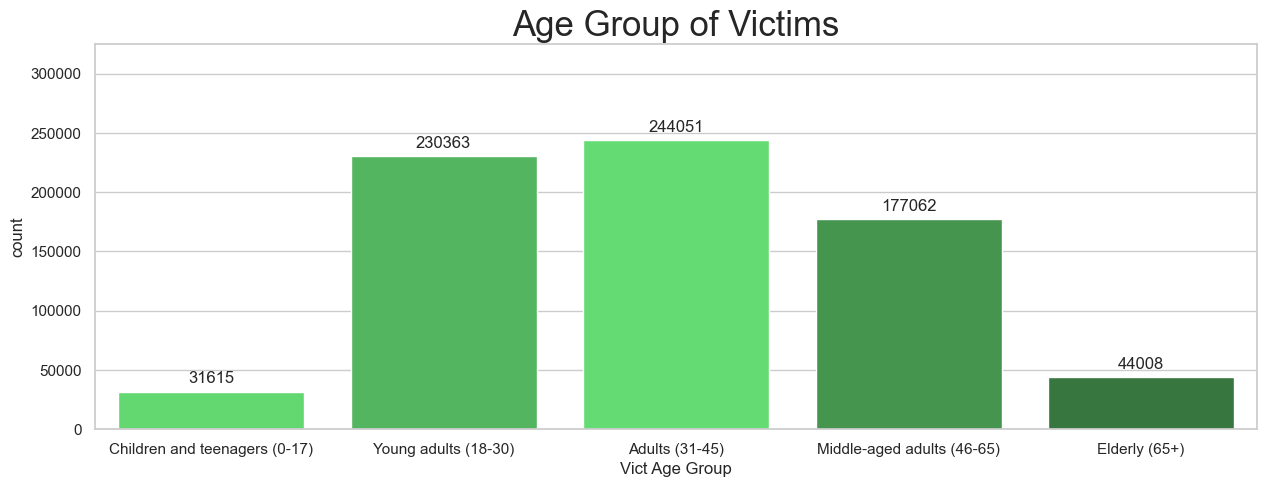

In [34]:
colors = ["#50EB62", "#43C552", "#51F064", "#37A344", "#2C8136", "#00610B",
          "#50EB62", "#43C552", "#51F064", "#37A344", "#2C8136", "#00610B"]

age_bins = [0, 18, 31, 46, 66, 120]

crimes["Vict Age Bin"] = pd.cut(crimes["Vict Age"], bins=age_bins, include_lowest=True)
crimes["Vict Age Bin"] = crimes["Vict Age Bin"].apply(lambda x: f"({int(x.left)}, {int(x.right)}]")

agebins_labels = {
    "(0, 18]": "Children and teenagers (0-17)",
    "(18, 31]": "Young adults (18-30)",
    "(31, 46]": "Adults (31-45)",
    "(46, 66]": "Middle-aged adults (46-65)",
    "(66, 120]": "Elderly (65+)"
}

crimes["Vict Age Group"] = crimes["Vict Age Bin"].map(agebins_labels)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

ax = sns.countplot(x="Vict Age Group", data=crimes, hue="Vict Age Group", palette=colors, dodge=False)
plt.title("Age Group of Victims", fontsize=25)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)

plt.ylim(0, 325000)
plt.show()

## **e) Time of Crime Occurrence**

The time when the most of crimes are committed is after 15:00 and 18:00, followed by 18:00 to 21:00.

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\988365630.py:8: UserWarning: The palette list has more values (12) than needed (8), which may not be intended.
  ax = sns.countplot(x="TIME OCC Bin", data=crimes, hue="TIME OCC Bin",palette= colors, dodge=False)


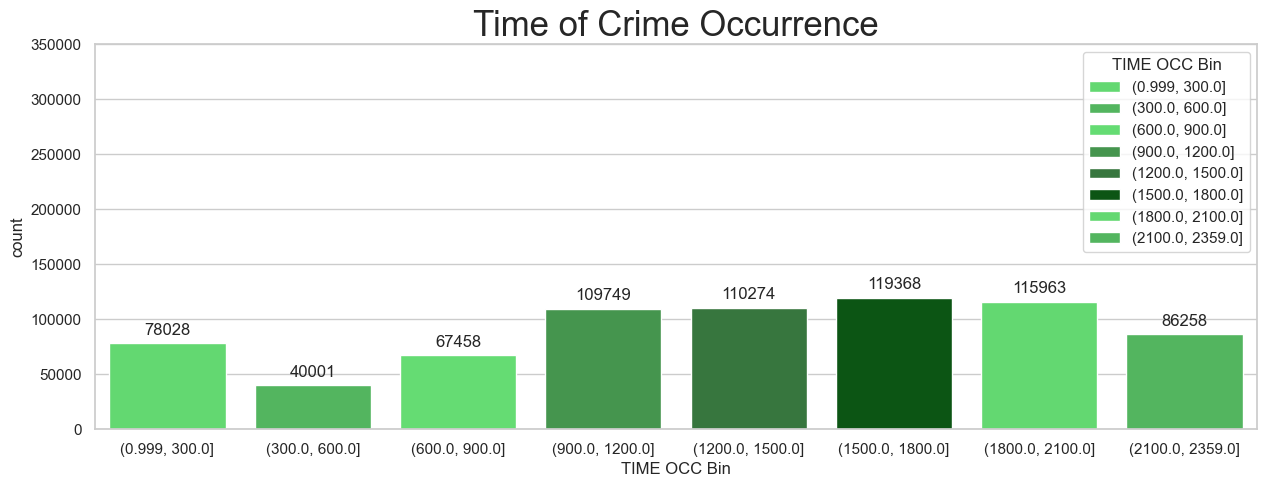

In [35]:
timeocc_bins = [1, 300, 600, 900, 1200, 1500, 1800, 2100, 2359]

crimes ["TIME OCC Bin"] = pd.cut(crimes["TIME OCC"], bins=timeocc_bins, include_lowest=True) # Bins fo the age data

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

ax = sns.countplot(x="TIME OCC Bin", data=crimes, hue="TIME OCC Bin",palette= colors, dodge=False)
plt.title("Time of Crime Occurrence", fontsize=25)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 350000)
plt.show()

## **f) Correlation between numerical variables**

<Axes: title={'center': 'Correlation Heatmap of Crimes'}>

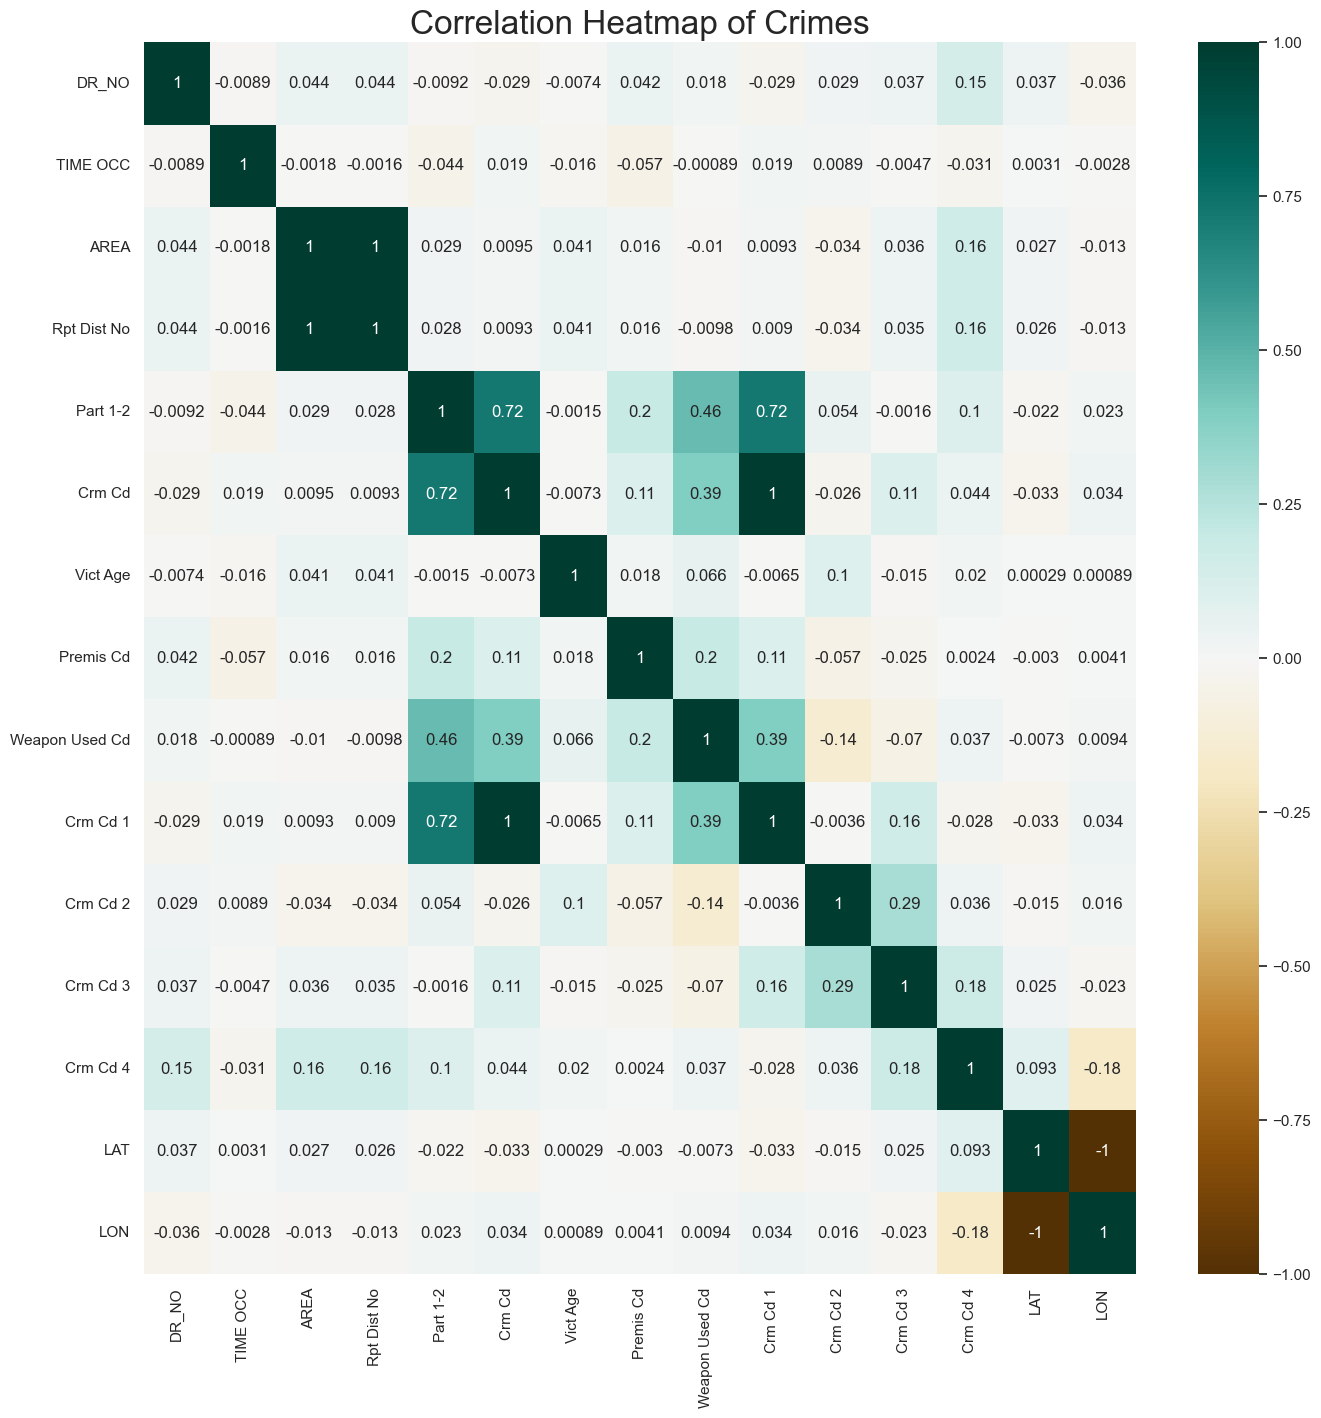

In [36]:
crimes_nums = crimes.select_dtypes(include=["number"])
plt.figure(figsize = (16, 16))

heatmap = sns.heatmap (crimes_nums.corr(),vmin = -1, vmax = 1, annot = True,  cmap = "BrBG")
heatmap.set_title("Correlation Heatmap of Crimes", fontsize=24)
heatmap

### **h) Dates of Occurrence vs Date of Report**

In [37]:
# Date of Occcurence
crimes["DATE OCC"] = pd.to_datetime(crimes["DATE OCC"], format="%m/%d/%Y %I:%M:%S %p")
crimes["Year OCC"] =  crimes["DATE OCC"].dt.year
crimes["Month OCC"] = crimes["DATE OCC"].dt.month
crimes["Day OCC"] =  crimes["DATE OCC"].dt.day
crimes["Day Name OCC"] = crimes["DATE OCC"].dt.day_name()


# Date Reported
crimes["Date Rptd"] = pd.to_datetime(crimes["Date Rptd"], format="%m/%d/%Y %I:%M:%S %p")
crimes["Year Rptd"] =  crimes["Date Rptd"].dt.year
crimes["Month Rptd"] = crimes["Date Rptd"].dt.month
crimes["Day Rptd"] =  crimes["Date Rptd"].dt.day
crimes["Day Name Rptd"] = crimes["Date Rptd"].dt.day_name()

### **Date Reported vs Date of Occurrence of the Crime Committed**

* 2024 represents the year with more difference in date and time between the date the crime occurred and this was reported.

In [38]:
crimes["Reported after Occurrence"] =  (crimes["Date Rptd"] - crimes["DATE OCC"]).dt.days

rptvsocc = (crimes[["Year Rptd", "Reported after Occurrence"]]
            .groupby(["Year Rptd"], as_index=False).mean()
            .sort_values(by="Reported after Occurrence", ascending=False).round(2)
            .astype({"Reported after Occurrence": "int"}))

rptvsocc

,Year Rptd,Reported after Occurrence
4,2024,27
3,2023,17
2,2022,14
1,2021,10
0,2020,4


## **i) Status of Report per year reported**

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\1126429888.py:4: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  ax = sns.countplot(x="Year Rptd", data=crimes, hue="Status Desc", palette= colors,)


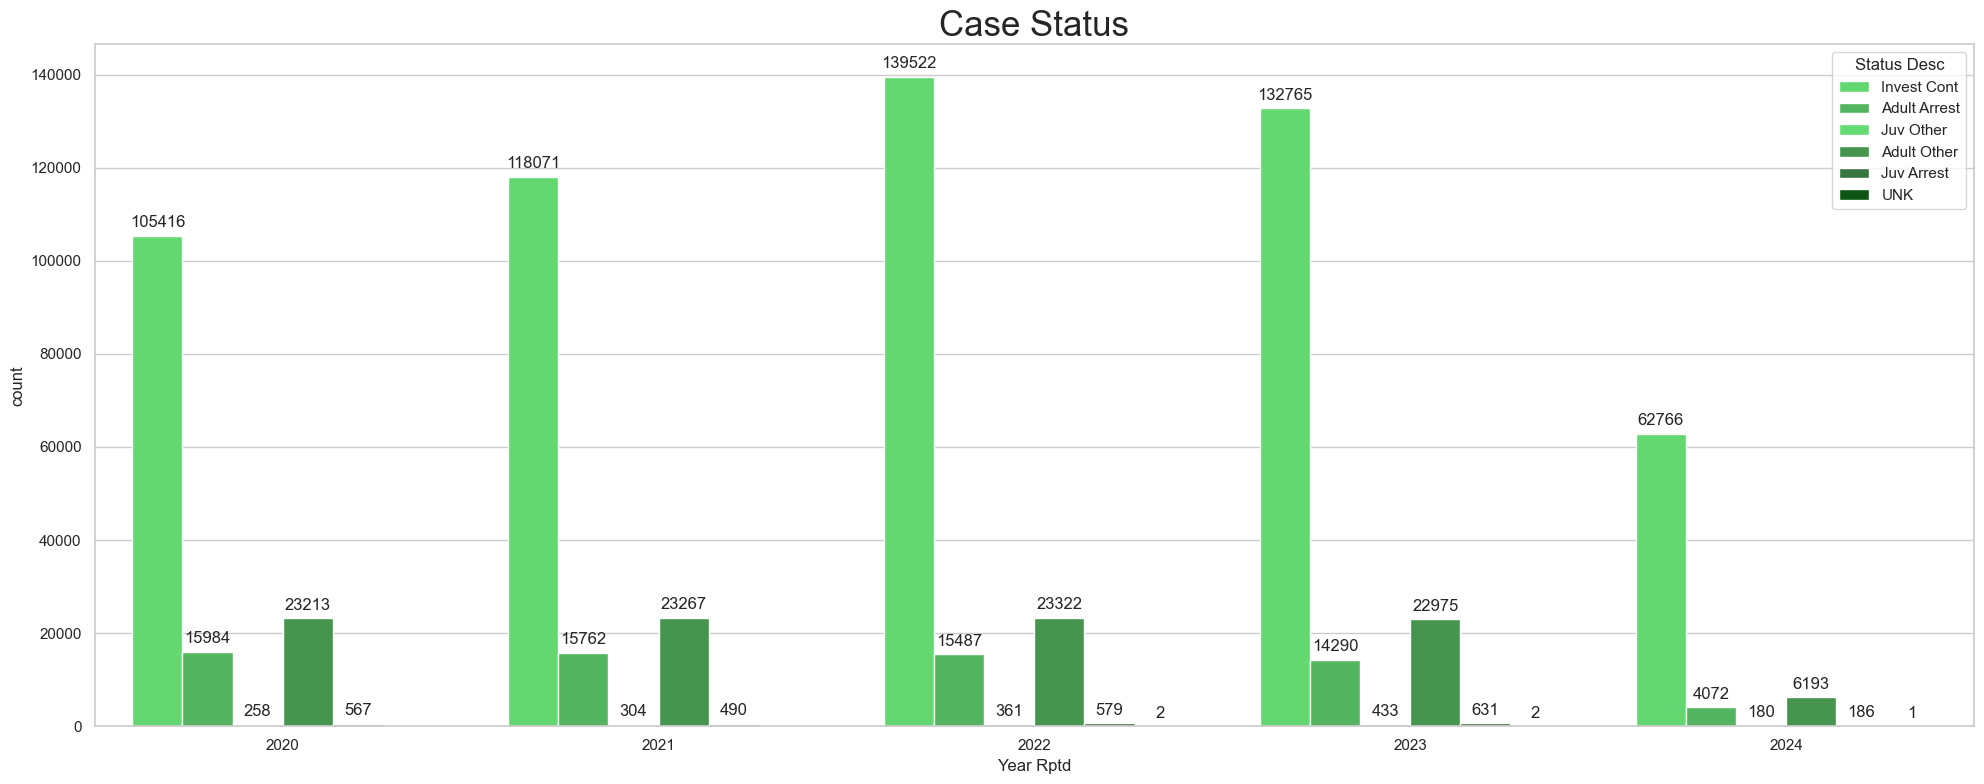

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))

ax = sns.countplot(x="Year Rptd", data=crimes, hue="Status Desc", palette= colors,)
for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.title("Case Status", fontsize=25)
plt.tight_layout()
plt.show()

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\1631936342.py:6: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(x="Year OCC", data=crimes, hue="Year OCC", palette= colors, ax=axes[0])
C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\1631936342.py:14: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(x="Year Rptd", data=crimes, hue="Year Rptd", palette= colors, ax=axes[1])


<Figure size 1000x400 with 0 Axes>

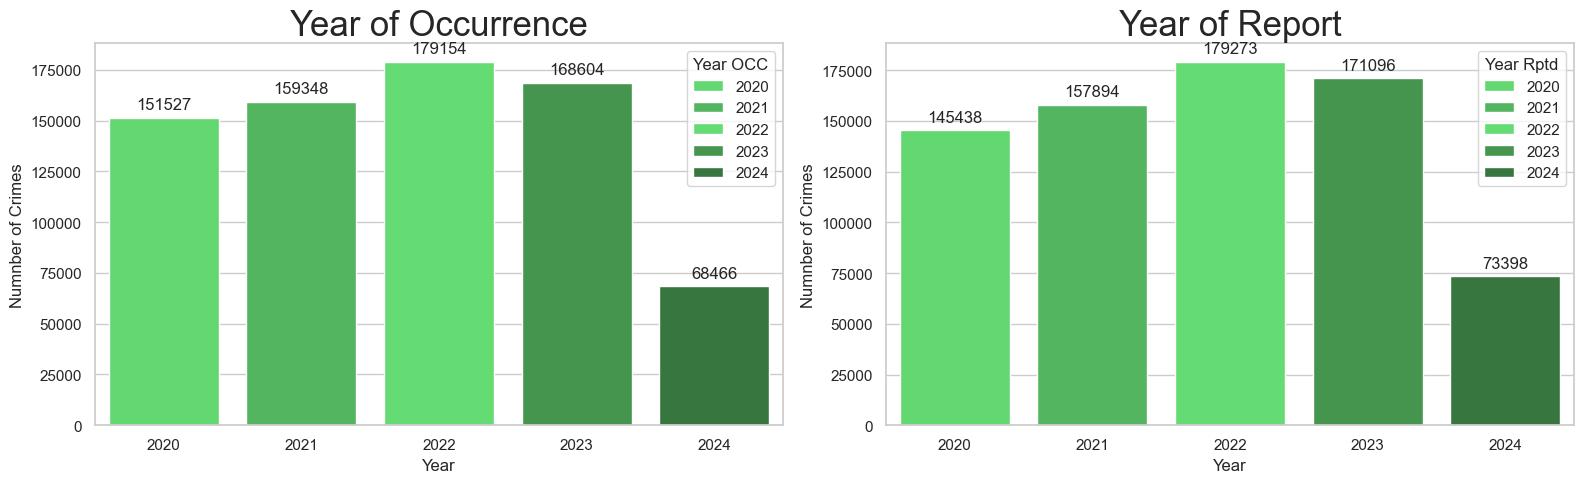

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))

fix, axes = plt.subplots(1,2, figsize=(16,5), sharey=False)

sns.countplot(x="Year OCC", data=crimes, hue="Year OCC", palette= colors, ax=axes[0])
axes[0].set_title("Year of Occurrence", fontsize=25)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Numnber of Crimes")

for p in axes[0].containers:
    axes[0].bar_label(p, label_type="edge", fmt="%.0f", padding=4)

sns.countplot(x="Year Rptd", data=crimes, hue="Year Rptd", palette= colors, ax=axes[1])
axes[1].set_title("Year of Report", fontsize=25)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Numnber of Crimes")

for p in axes[1].containers:
    axes[1].bar_label(p, label_type="edge", fmt="%.0f", padding=4)

plt.tight_layout()
plt.show()

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\322395680.py:4: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(x="Month OCC", data=crimes, hue="Year OCC", palette= colors)


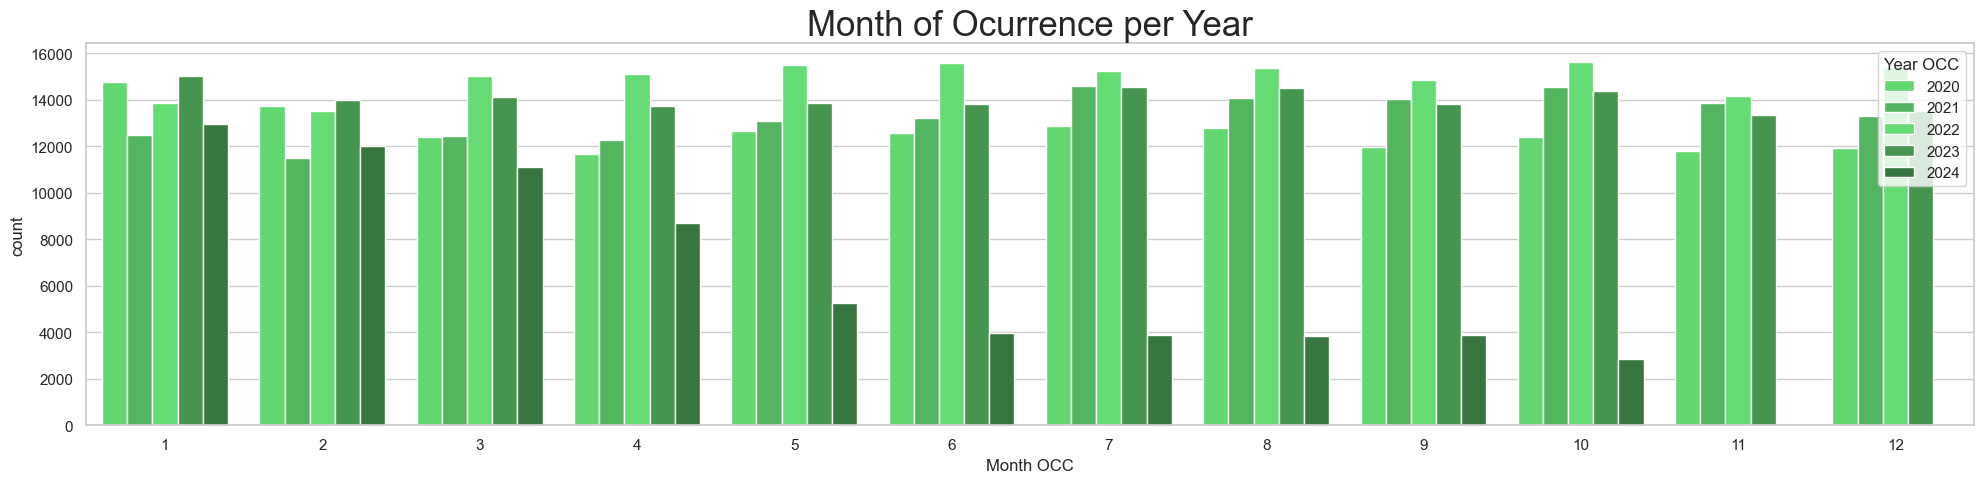

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))

sns.countplot(x="Month OCC", data=crimes, hue="Year OCC", palette= colors)
plt.title("Month of Ocurrence per Year", fontsize=25)
plt.tight_layout()
plt.show()

C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\2835690890.py:7: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(
C:\Users\cmanu\AppData\Local\Temp\ipykernel_23332\2835690890.py:21: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(


<Figure size 1000x500 with 0 Axes>

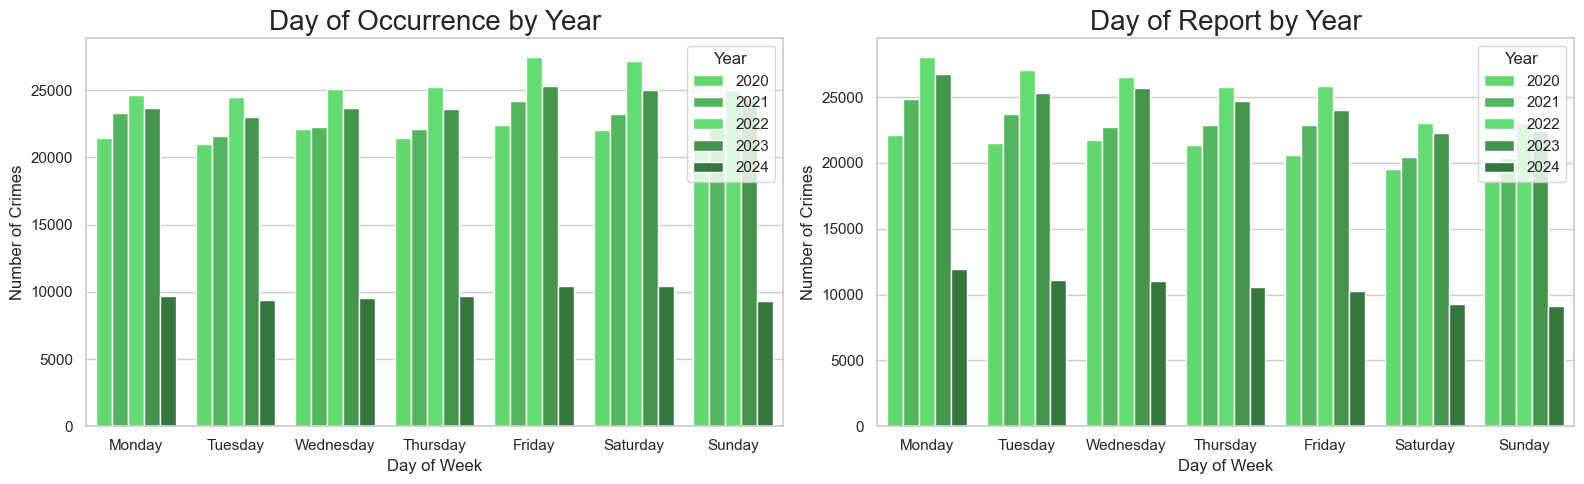

In [42]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Day of Occurrence by year
sns.countplot(
    x="Day Name OCC", 
    data=crimes, 
    hue="Year OCC", 
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], 
    palette=colors, 
    ax=axes[0]
)
axes[0].set_title("Day of Occurrence by Year", fontsize=20)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Crimes")
axes[0].legend(title="Year")

# Day of Report by year
sns.countplot(
    x="Day Name Rptd", 
    data=crimes, 
    hue="Year Rptd", 
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], 
    palette=colors, 
    ax=axes[1]
)
axes[1].set_title("Day of Report by Year", fontsize=20)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Crimes")
axes[1].legend(title="Year")

plt.tight_layout()
plt.show()

## **j) Ocurrence by Area**

In [43]:
crimes["AREA NAME"].value_counts()

Central        51268
Southwest      47136
77th Street    45867
Pacific        41508
Hollywood      38796
Southeast      36287
Olympic        35729
N Hollywood    35710
Wilshire       35263
Topanga        33966
Newton         33110
Van Nuys       33031
West LA        32800
Rampart        32677
West Valley    30602
Mission        29822
Northeast      28969
Devonshire     28862
Harbor         27467
Foothill       24345
Hollenbeck     23884
Name: AREA NAME, dtype: int64

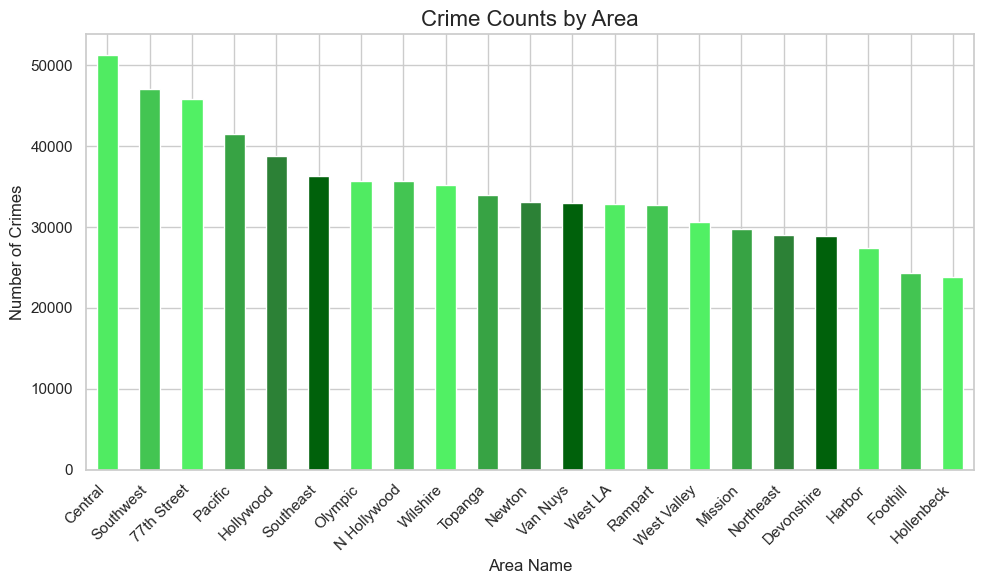

In [44]:
plt.figure(figsize=(10, 6))
crimes["AREA NAME"].value_counts().plot(kind="bar", color=colors)
plt.title("Crime Counts by Area", fontsize=16)
plt.xlabel("Area Name", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **1.3 Data Preparation**

In [45]:
nullpercentage = (crimes.isnull().sum().sort_values(ascending=False) / crimes.shape[0])*100
nullpercentage

Crm Cd 4                     99.991610
Crm Cd 3                     99.702654
Crm Cd 2                     92.548745
Cross Street                 84.350137
Weapon Desc                  58.697371
Weapon Used Cd               58.697371
Mocodes                       0.773485
Premis Desc                   0.049512
Premis Cd                     0.018154
Vict Sex                      0.004401
Vict Descent                  0.004401
Crm Cd 1                      0.000825
TIME OCC Bin                  0.000000
Year OCC                      0.000000
Month OCC                     0.000000
Day OCC                       0.000000
Day Name OCC                  0.000000
Year Rptd                     0.000000
Vict Age Group                0.000000
Vict Age Bin                  0.000000
LON                           0.000000
Month Rptd                    0.000000
Day Rptd                      0.000000
Day Name Rptd                 0.000000
LAT                           0.000000
DR_NO                    

## **Unnecessary or redundant columns**

In [46]:
columns_todrop = ["DR_NO", "Cross Street", "Date Rptd", "DATE OCC",
                   "AREA NAME", "Weapon Used Cd", "Mocodes", "Crm Cd Desc", "Premis Desc", 
                   "Weapon Desc", "LOCATION", "TIME OCC Bin", "Crm Cd 1", 
                    "Status", "Vict Age Bin",  "Crm Cd 3", "Crm Cd 4", "Part 1-2"
                   ]

crimes.drop(columns=columns_todrop, inplace=True)

## **Missing data**

In [47]:
def fillzero (crimesd, columns, fillwith=0):
    crimesd[columns] = crimes[columns].fillna(fillwith)

columns_tozero = ["Crm Cd 2"]
fillzero(crimes, columns_tozero, fillwith=0)

## **Dropping Critical missing data**

In [48]:
crimes = crimes.dropna(subset=["Premis Cd"])
crimes = crimes.dropna(subset=["Vict Sex"])
crimes = crimes.dropna(subset=["Vict Descent"])

In [49]:
nullpercentage = (crimes.isnull().sum().sort_values(ascending=False) / crimes.shape[0])*100
nullpercentage

TIME OCC                     0.0
AREA                         0.0
Day Name Rptd                0.0
Day Rptd                     0.0
Month Rptd                   0.0
Year Rptd                    0.0
Day Name OCC                 0.0
Day OCC                      0.0
Month OCC                    0.0
Year OCC                     0.0
Vict Age Group               0.0
LON                          0.0
LAT                          0.0
Crm Cd 2                     0.0
Status Desc                  0.0
Premis Cd                    0.0
Vict Descent                 0.0
Vict Sex                     0.0
Vict Age                     0.0
Crm Cd                       0.0
Rpt Dist No                  0.0
Reported after Occurrence    0.0
dtype: float64

## **Categorical into Numerical Data**

In [50]:
def transform_intonum (columns, crimes):
    labelenc = LabelEncoder()
    for column in columns:
        if crimes[column].nunique() < 150:
            crimes[column] = labelenc.fit_transform(crimes[column])
    
columns_tonum = ["Status Desc", "Vict Sex", "Vict Descent", "Vict Age Group", "Day Name Rptd", "Day Name OCC"]
transform_intonum(columns_tonum, crimes)

In [51]:
print(crimes.shape)
crimes.head()

(726931, 22)


,TIME OCC,AREA,Rpt Dist No,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Status Desc,Crm Cd 2,LAT,LON,Vict Age Group,Year OCC,Month OCC,Day OCC,Day Name OCC,Year Rptd,Month Rptd,Day Rptd,Day Name Rptd,Reported after Occurrence
1,1800,1,182,330,47,2,12,128.0,2,998.0,34.0444,-118.2628,3,2020,2,8,2,2020,2,9,3,1
2,1700,3,356,480,19,3,18,502.0,2,0.0,34.0210,-118.3002,4,2020,11,4,6,2020,11,11,6,7
3,2037,9,964,343,19,2,12,405.0,2,0.0,34.1576,-118.4387,4,2020,3,10,5,2023,5,10,6,1156
4,1200,6,666,354,28,2,7,102.0,2,0.0,34.0944,-118.3277,4,2020,8,17,1,2022,8,18,4,731
5,2300,18,1826,354,41,2,7,501.0,2,0.0,33.9467,-118.2463,0,2020,12,1,5,2023,4,4,5,854


<Axes: title={'center': 'Correlation Heatmap of Crimes'}>

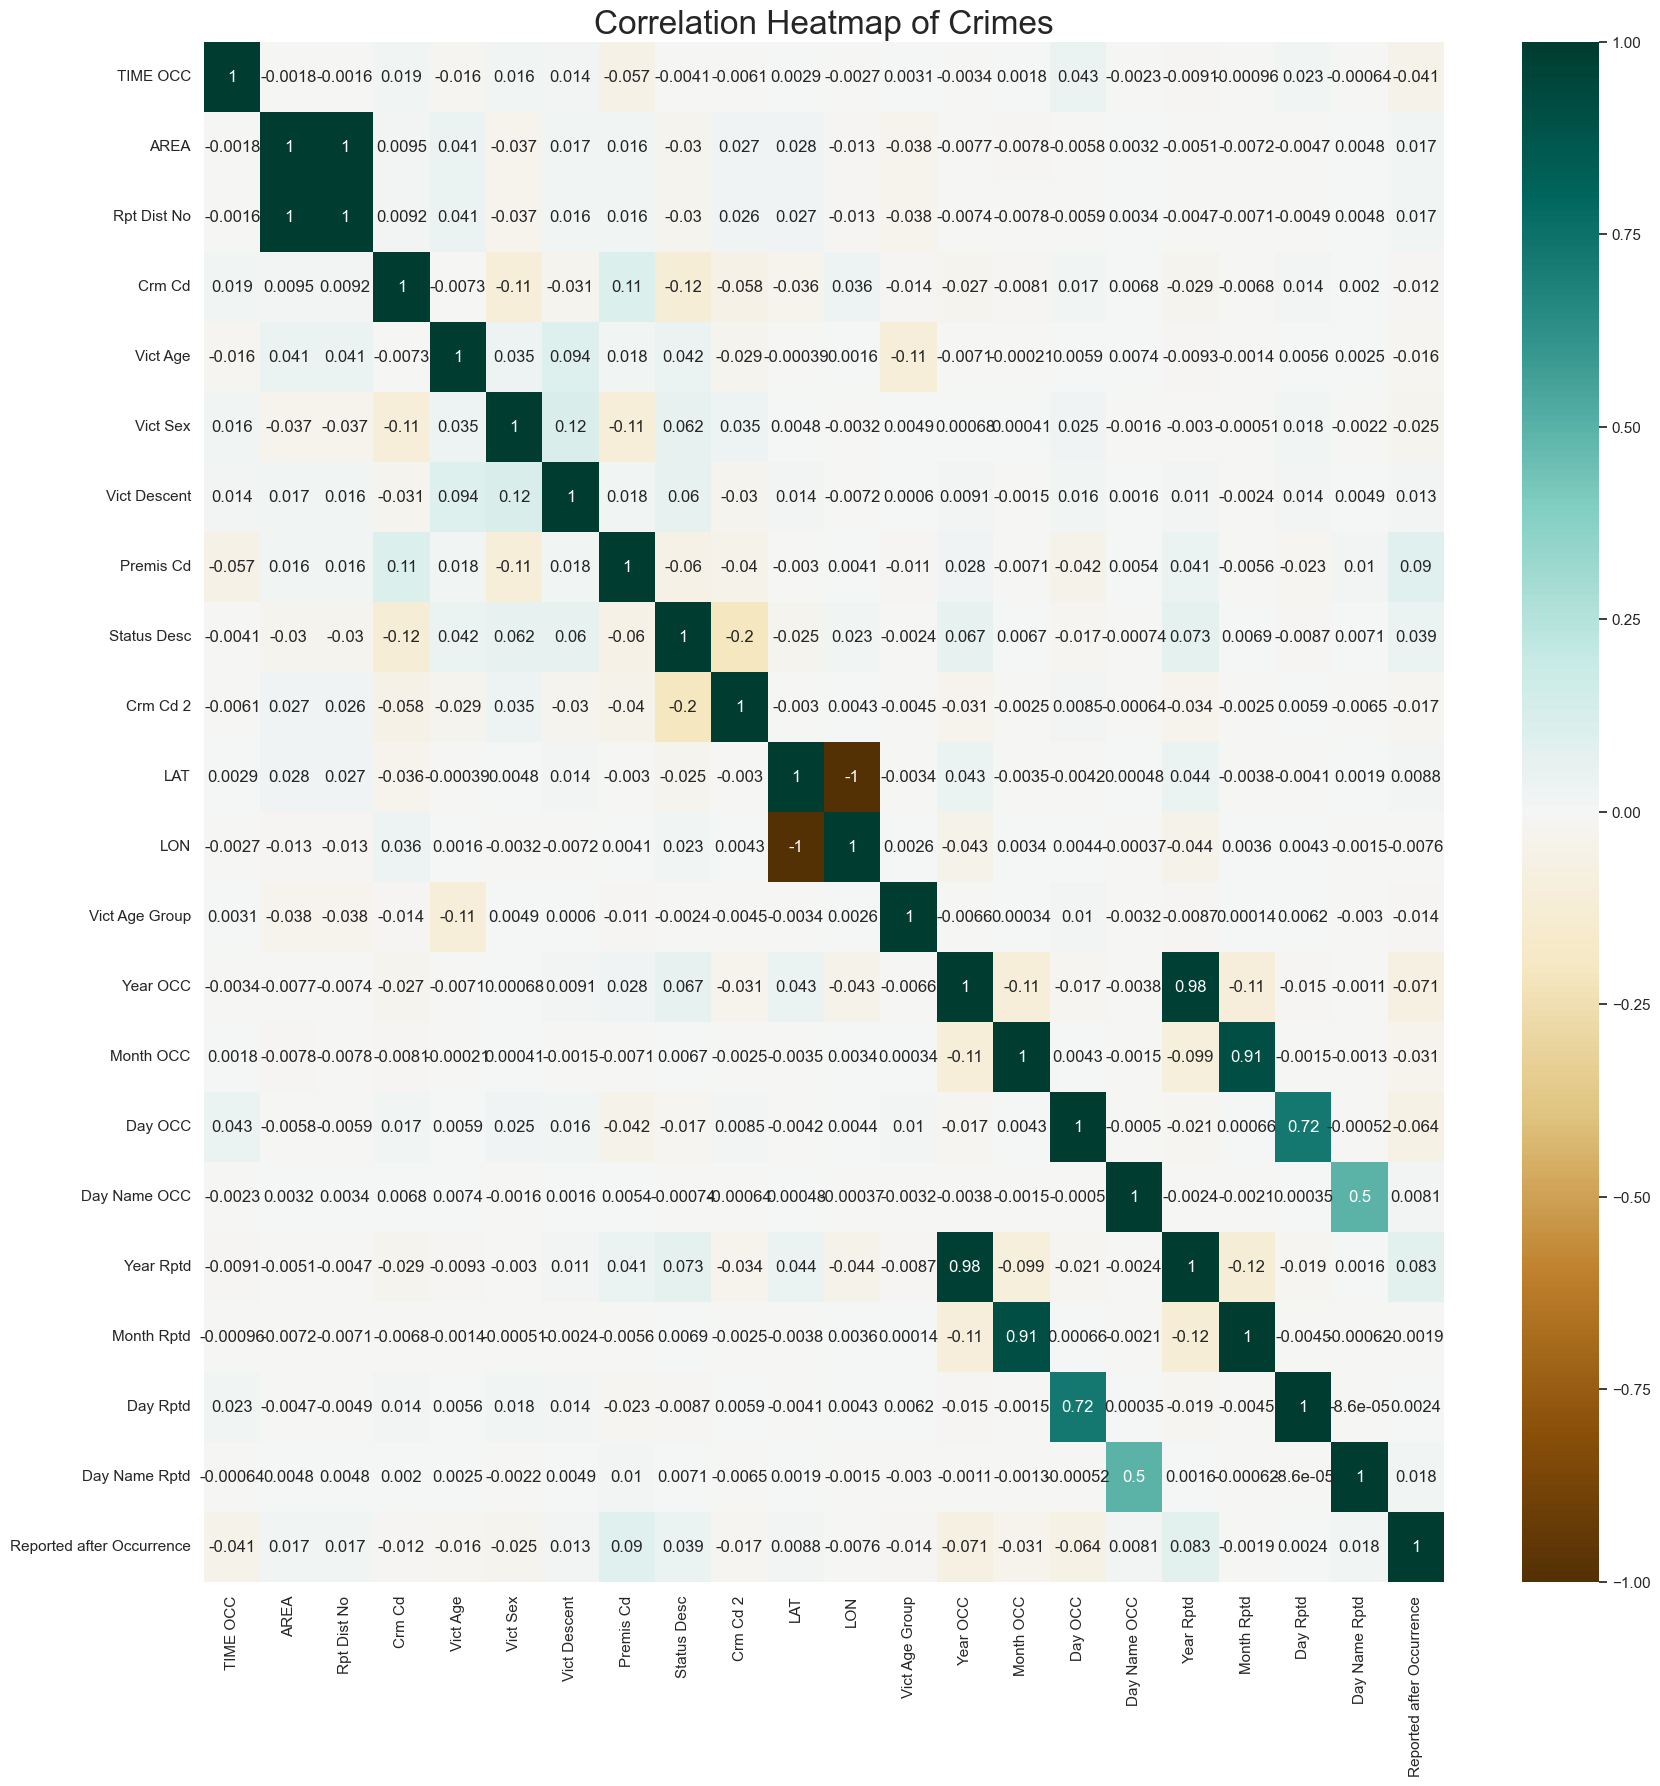

In [52]:
crimes_nums = crimes.select_dtypes(include=["number"])
plt.figure(figsize = (20, 20))

heatmap = sns.heatmap (crimes_nums.corr(),vmin = -1, vmax = 1, annot = True,  cmap = 'BrBG')
heatmap.set_title("Correlation Heatmap of Crimes", fontsize=24)
heatmap

In [53]:
nullpercentage = (crimes.isnull().sum().sort_values(ascending=False) / crimes.shape[0])*100
nullpercentage

TIME OCC                     0.0
AREA                         0.0
Day Name Rptd                0.0
Day Rptd                     0.0
Month Rptd                   0.0
Year Rptd                    0.0
Day Name OCC                 0.0
Day OCC                      0.0
Month OCC                    0.0
Year OCC                     0.0
Vict Age Group               0.0
LON                          0.0
LAT                          0.0
Crm Cd 2                     0.0
Status Desc                  0.0
Premis Cd                    0.0
Vict Descent                 0.0
Vict Sex                     0.0
Vict Age                     0.0
Crm Cd                       0.0
Rpt Dist No                  0.0
Reported after Occurrence    0.0
dtype: float64

In [54]:
print(crimes.shape)
crimes

(726931, 22)


,TIME OCC,AREA,Rpt Dist No,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Status Desc,Crm Cd 2,LAT,LON,Vict Age Group,Year OCC,Month OCC,Day OCC,Day Name OCC,Year Rptd,Month Rptd,Day Rptd,Day Name Rptd,Reported after Occurrence
1,1800,1,182,330,47,2,12,128.0,2,998.0,34.0444,-118.2628,3,2020,2,8,2,2020,2,9,3,1
2,1700,3,356,480,19,3,18,502.0,2,0.0,34.0210,-118.3002,4,2020,11,4,6,2020,11,11,6,7
3,2037,9,964,343,19,2,12,405.0,2,0.0,34.1576,-118.4387,4,2020,3,10,5,2023,5,10,6,1156
4,1200,6,666,354,28,2,7,102.0,2,0.0,34.0944,-118.3277,4,2020,8,17,1,2022,8,18,4,731
5,2300,18,1826,354,41,2,7,501.0,2,0.0,33.9467,-118.2463,0,2020,12,1,5,2023,4,4,5,854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990285,2345,1,142,440,42,0,2,122.0,2,0.0,34.0531,-118.2512,0,2024,9,27,0,2024,10,4,0,7
990286,2300,20,2033,341,36,0,3,207.0,2,0.0,34.0617,-118.3066,0,2024,8,17,2,2024,8,20,5,3
990287,1546,14,1489,341,46,2,7,223.0,2,0.0,33.9469,-118.3703,0,2024,10,16,6,2024,10,16,6,0
990290,2330,4,421,341,29,2,2,210.0,2,0.0,34.0675,-118.2240,4,2024,10,11,0,2024,10,14,1,3


<Axes: title={'center': 'Correlation Heatmap of Crimes'}>

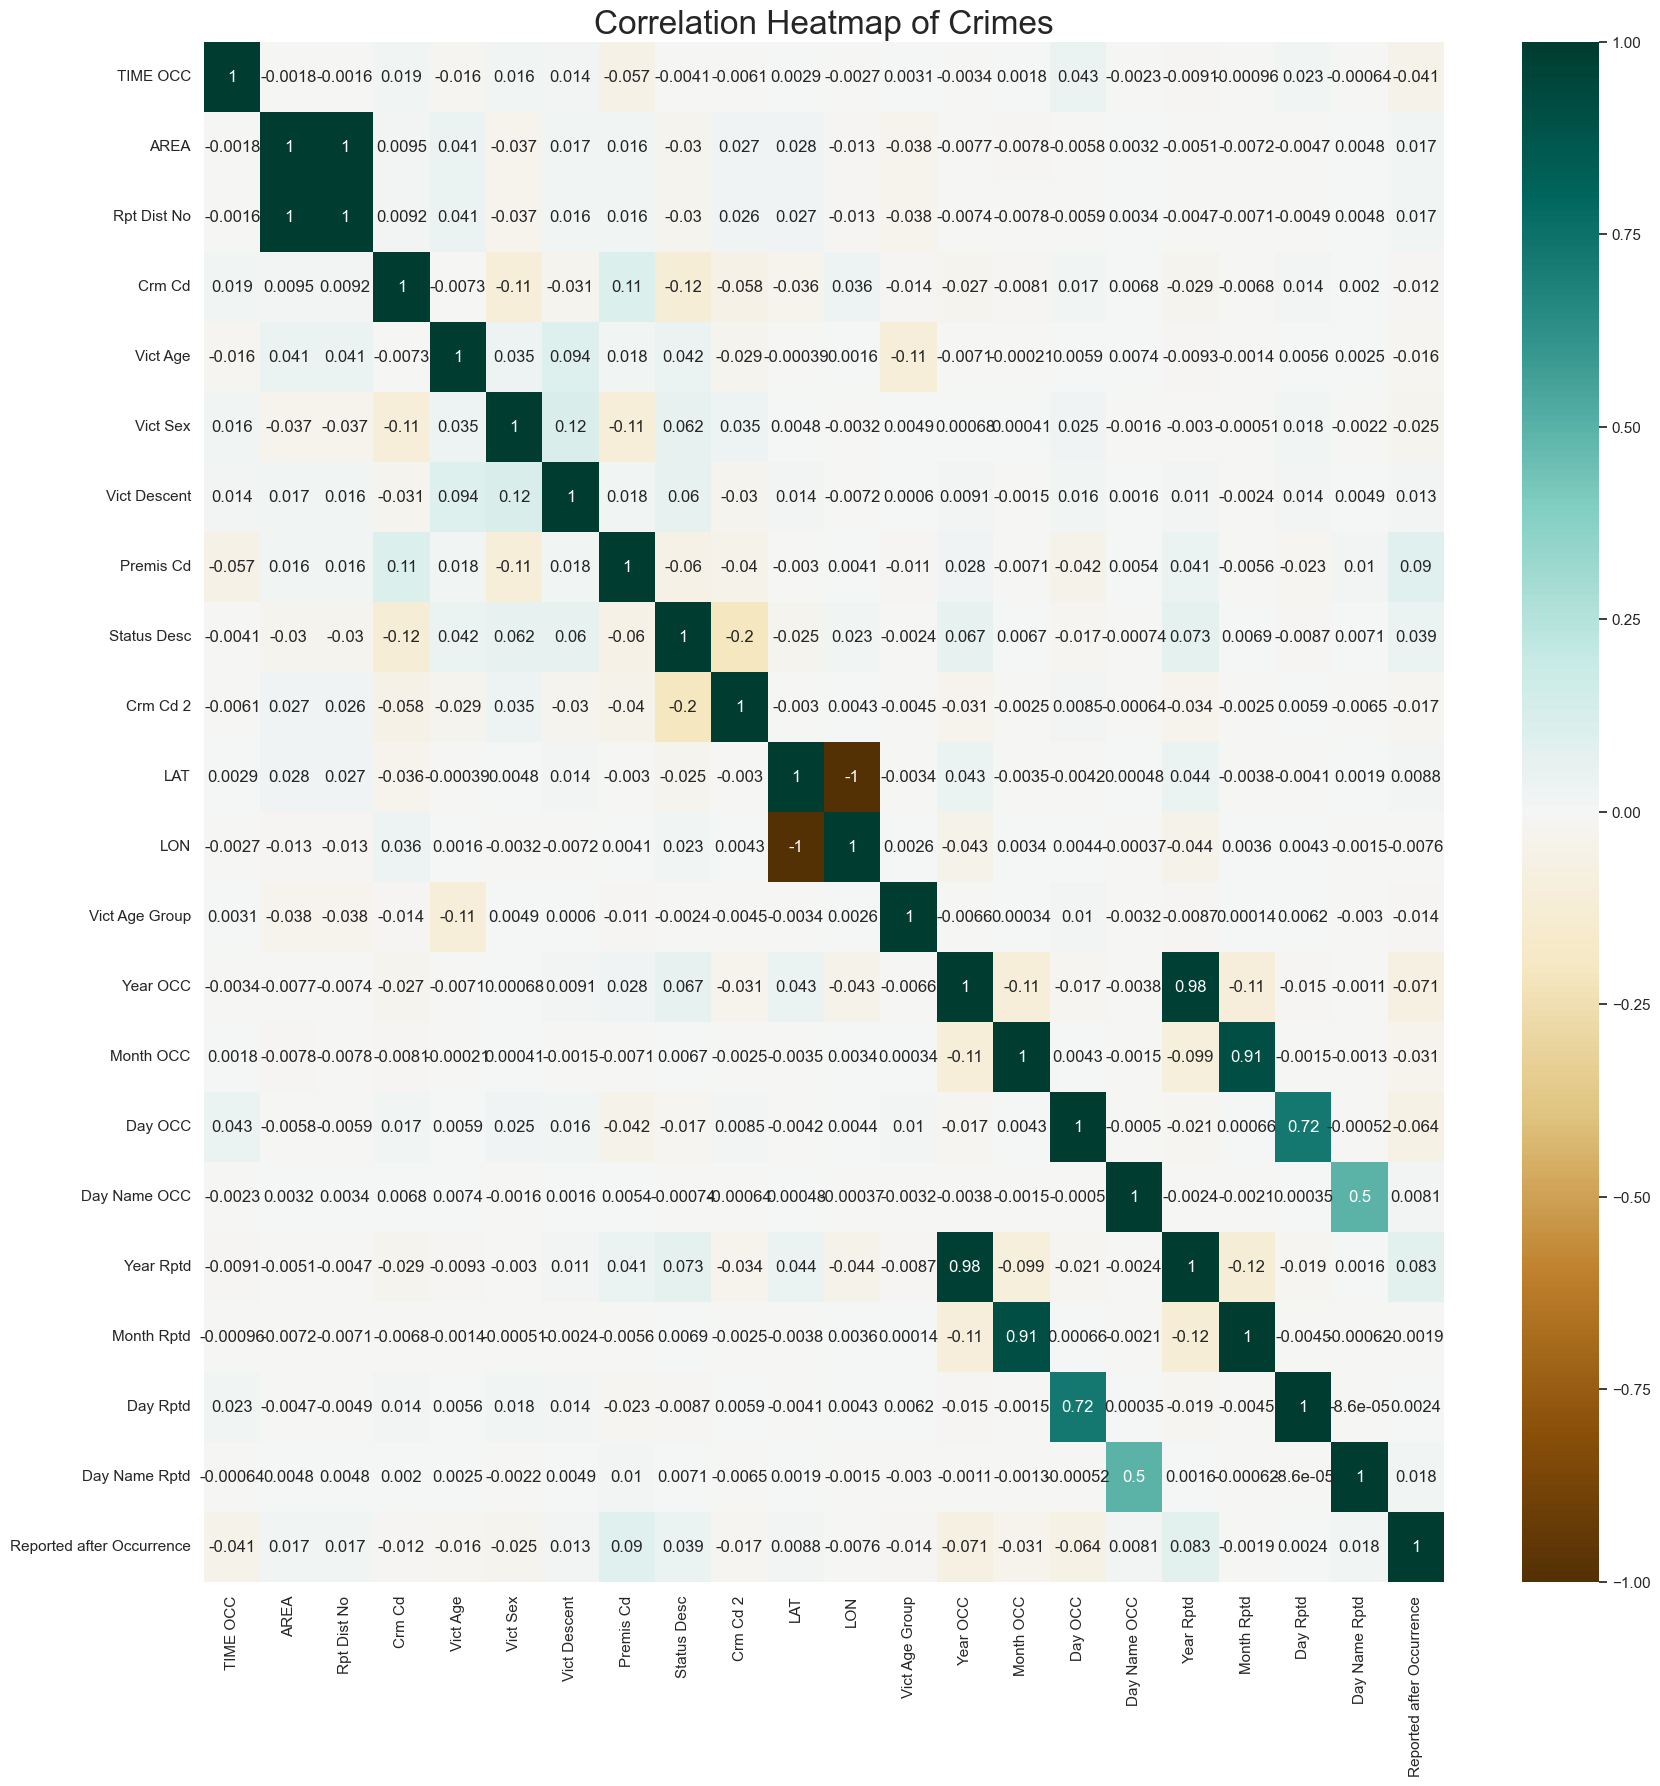

In [55]:
crimes_nums = crimes.select_dtypes(include=["number"])
plt.figure(figsize = (20,20))

heatmap = sns.heatmap (crimes_nums.corr(),vmin = -1, vmax = 1, annot = True,  cmap = 'BrBG')
heatmap.set_title("Correlation Heatmap of Crimes", fontsize=24)
heatmap

In [56]:
crimes.dtypes

TIME OCC                       int64
AREA                           int64
Rpt Dist No                    int64
Crm Cd                         int64
Vict Age                       int64
Vict Sex                       int32
Vict Descent                   int32
Premis Cd                    float64
Status Desc                    int32
Crm Cd 2                     float64
LAT                          float64
LON                          float64
Vict Age Group                 int32
Year OCC                       int64
Month OCC                      int64
Day OCC                        int64
Day Name OCC                   int32
Year Rptd                      int64
Month Rptd                     int64
Day Rptd                       int64
Day Name Rptd                  int32
Reported after Occurrence      int64
dtype: object

# **1.4 Modeling**

In [57]:
columns_to_drop = ["Vict Age"]

Y_train = crimes["Vict Age"]
X_train = crimes.drop(columns_to_drop, axis=1)

X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

# All sets train and set respectively contain the same amount of values to avoid error in processing time
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape)

(581544, 21) (581544,) (145387, 21) (145387,)


In [58]:
common_columns = X_train.columns.intersection(X_val.columns)
X_train = X_train[common_columns]
X_val = X_val[common_columns]

## **a) Decision Tree**

In [59]:
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train, Y_train)

# Predictions for Decision Tree Regressor
Y_preddt = decision_tree.predict(X_val)
Y_preddt = np.round(Y_preddt)

## **b) Neural Network: Multi-Layer Perceptron (MLP)**

In [60]:
# Standarization of Values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [61]:
# First and Second hidden layer
# Third is Output layer with no activation function to get a continuous value

mlp = keras.Sequential([
    layers.Dense(64, activation="relu"),  
    layers.Dense(64, activation="relu"),  
    layers.Dense(1) ])

mlp.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])

early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = mlp.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stopping]
)

Epoch 1/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 197.1699 - mae: 9.7234 - val_loss: 23.8991 - val_mae: 3.9867
Epoch 2/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 22.6762 - mae: 3.8945 - val_loss: 21.7308 - val_mae: 3.8291
Epoch 3/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 22.1256 - mae: 3.8545 - val_loss: 21.7609 - val_mae: 3.8393
Epoch 4/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 21.8496 - mae: 3.8370 - val_loss: 21.4878 - val_mae: 3.8144
Epoch 5/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - loss: 21.7692 - mae: 3.8252 - val_loss: 21.4014 - val_mae: 3.8037
Epoch 6/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 21.6660 - mae: 3.8203 - val_loss: 21.5161 - val_mae: 3.8295
Epoch 7/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 21.5115 - mae: 3.8047 - val_loss: 21.3845 - val_mae: 3.7955
Epoch 8/10
14539/14539 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 21.5003 - mae: 3.8046 - val_loss: 21.1875 - val_mae: 3.7878

## **c) First Ten Predictions**

In [62]:
# Actual values
tenpred = list(Y_val[0:10])
print(tenpred)

# Decision Tree
print(f"First 10 Predictions (Decision Tree): {Y_preddt[:10]}")

# Multilayer Perceptron (MLP) Predictions
Y_predmlp = mlp.predict(X_val)
Y_predmlp = np.round(Y_predmlp.flatten())
print(f"First 10 Predictions (MLP): {Y_predmlp[:10]}")

[74, 27, 24, 53, 61, 29, 20, 44, 20, 78]
First 10 Predictions (Decision Tree): [76. 27. 23. 57. 61. 25. 23. 32. 30. 74.]
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
First 10 Predictions (MLP): [73. 25. 25. 57. 54. 25. 25. 38. 25. 74.]


# **1.5 Evaluation**

# **a) Decision tree**

In [63]:
pd.set_option("display.float_format", "{:.4f}".format)

mae_dt = mean_absolute_error(Y_val, Y_preddt)
mse_dt = mean_squared_error(Y_val, Y_preddt)
r2_dt = r2_score(Y_val, Y_preddt)
rmse_dt = np.sqrt(mse_dt)
rss_dt = np.sum((Y_val - Y_preddt) ** 2)

metrics = pd.DataFrame({
    "Metric": ["R-Squared", "Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "Residual Sum of Squares (RSS)"],
    "Value": [r2_dt, mae_dt, mse_dt, rmse_dt, rss_dt]
})

metrics

,Metric,Value
0,R-Squared,0.8367
1,Mean Absolute Error (MAE),4.8316
2,Mean Squared Error (MSE),39.7108
3,Root Mean Squared Error (RMSE),6.3017
4,Residual Sum of Squares (RSS),5773435.0000


In [68]:
# Cross Validation
cv_scores = cross_val_score(decision_tree, X_train, Y_train, cv=5, scoring="neg_mean_squared_error")
print("Cross-validation scores:", -cv_scores)

Cross-validation scores: [39.94814281 39.69928571 40.08289395 39.98106743 39.87895818]


In [73]:
cvmean = -cv_scores.mean()
cvmean.round(2)

39.92

## **b)  MLP**

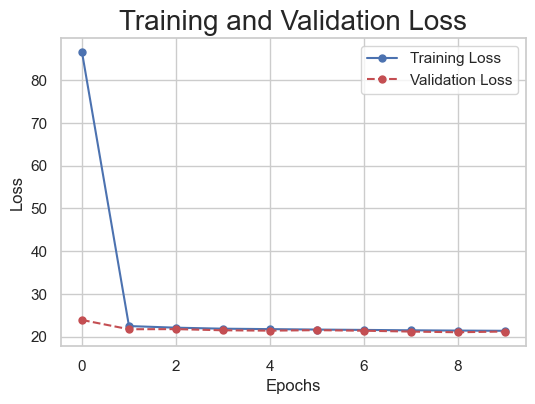

In [69]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training Loss", marker="o", markersize=5, linestyle="-", color="b")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="o", markersize=5, linestyle="--", color="r")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss", fontsize=20)
plt.legend()
plt.show()

In [74]:
loss, mae = mlp.evaluate(X_val, Y_val)
mse_mlp = np.mean((Y_val - Y_predmlp) ** 2)
rmse_mlp = np.sqrt(mse_mlp)
rss_mlp = np.sum((Y_val - Y_predmlp) ** 2)
r2_mlp  = r2_score(Y_val, Y_predmlp)

print(f"Validation R-Squared: {r2_mlp:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation Loss (MSE): {loss:.4f}")
print(f"Validation RMSE: {rmse_mlp:.4f}")
print(f"Validation RSS: {rss_mlp:.4f}")

4544/4544 ━━━━━━━━━━━━━━━━━━━━ 4s 806us/step - loss: 21.1222 - mae: 3.7614
Validation R-Squared: 0.9128
Validation MAE: 3.7691
Validation Loss (MSE): 21.1393
Validation RMSE: 4.6045
Validation RSS: 3082380.0000
